In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from itertools import product
import hexMinisom
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf
import pickle
import sammon
import itertools
import colorsys
import random
import datetime as dt

In [2]:
def save_som(som, fileName):
    with open(fileName, 'wb') as outfile:
        pickle.dump(som, outfile)

def load_som(fileName):
    with open(fileName, 'rb') as infile:
        som = pickle.load(infile)
    return som

def generate_distinct_colors(n):
    colors = []
    # Generate `n` distinct colors in the HSV color space
    for i in range(n):
        # Generate a unique hue for each color, evenly spaced between 0 and 1
        hue = i / n
        # Use full saturation and value to get vibrant colors
        saturation = 1.0
        value = 1.0
        
        # Convert HSV to RGB (the result is a tuple of RGB values in [0, 1])
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        
        # Convert RGB to a format that ranges from 0 to 255 and create a hex string
        rgb = [int(x * 255) for x in rgb]
        hex_color = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        colors.append(hex_color)
    random.shuffle(colors)
    return colors

# Get the counts of each WR_label for each node in SOM
def get_WR_counts(l, return_percents=False, indices=None):

    # Take only the data from days with the given indices in indices
    if indices is None:
        labels, counts = np.unique([WR_labels[i] for i in l], return_counts=True)
    else:
        labels, counts = np.unique([WR_labels[i] for i in l if i in indices], return_counts=True)

    # If the node has no days of a given regime add the regime to the labels and 0 as its count
    if len(labels) != len(WR_labels_dict.keys()):
        missing_values = np.setdiff1d(list(WR_labels_dict.keys()), labels)
        labels = WR_labels_dict.keys()

        for v in missing_values:
           counts = np.insert(counts, v, 0)

    # Calculate the percents
    if return_percents:
        counts = 100 * counts / sum(counts)
    regime_counts = dict(zip(labels, counts))
    return regime_counts

# Plotting functions
def hex_heatmap(som, data, cmap='Blues', title='', cbLabel=''):
    # set up the figure
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    ax.set_aspect('equal')
    cmap = mpl.colormaps[cmap]
    
    # get data from the som
    weights = som.get_weights()
    xx, yy = som.get_euclidean_coordinates()
    
    maxCount = max(v for v in data.values())
    #maxCount = 553  #frequency
    #maxCount = 4.39   #persistence
    minCount = min(v for v in data.values())
    #minCount = 65    #frequency
    #minCount = 1.23   #persistence
    
    # loops through the neurons
    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            # Only use non-masked nodes
            if som._mask[i, j] == 0:
                # If theres no data still plot the hexagon
                if (i, j) not in data:
                    data[(i,j)] = 0
                    
                # determine the hexagon position and color
                wy = yy[(j, i)] * np.sqrt(3) / 2
                colorWeight = data[(i, j)]/maxCount
                
                # Create hexagon and add it to axis
                hex = patches.RegularPolygon(
                    (xx[(j, i)], wy), numVertices=6, radius=.85 / np.sqrt(3), 
                    facecolor=cmap(colorWeight), edgecolor='grey')
                ax.add_patch(hex)
                
                # determine the color the text should be based on color of node
                if colorWeight >= .75:
                    textColor = 'white'
                else:
                    textColor = 'black'
                
                # add text to hexagon for its frequency
                plt.text(
                    xx[(j, i)], wy - .07, f'{data[(i, j)]}', 
                    {'horizontalalignment': 'center', 'color': textColor, 'fontsize': 17})
            
    # align figure to show all hexagons
    plt.xlim(-1, weights.shape[0] - .5)
    plt.ylim(-1, (weights.shape[1] - .5) * np.sqrt(3) / 2)
    
    # remove the axis labels and lines
    ax.axis('off')
    
    # Create the color bar
    norm = mpl.colors.Normalize(vmin=minCount, vmax=maxCount)
    cb = fig.colorbar(mpl.cm.ScalarMappable(
        norm=norm, cmap=cmap), ax=ax, location='bottom', anchor=(.56, 2.3), shrink=.65, extend='both')
    cb.set_label(cbLabel, fontsize=17)
    cb.ax.tick_params(labelsize=17)
    
    # Title the plot
    plt.title(title, fontsize=17, y=.95, x=.515)
    return fig

def hex_frequency_plot(som, winmap=None):

    if winmap == None:
        winmap = som.win_map(dataarray)
    
    data = {k: len(v) for k, v in winmap.items()}
    
    fig = hex_heatmap(som, data, 'Blues', '(a) SOM Node Frequencies', 'Count')
    return fig

def hex_plot(som, projection=None):
    """Create a matplot lib figure with an axis for each neuron already positioned into the hexagonal shape"""
    
    # Extract the needed data from the som
    n = som._num
    xy = (2 * n) - 1
    mask = som._mask
    node_indices_xy = np.ma.where(mask == False)
    node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))

    # create figure
    totRows = xy * 3
    totCols = xy * 2
    fig = plt.figure(figsize=[totRows, totCols])
    axs = {}
    
    for x, y in list(product(range(xy), range(xy))):

        # make a subplot for the nodes not masked
        if (y, x) in node_indices: # for showing in the proper orientation x and y must be switched
            
            # odd rows will be offset to keep the hexagonal shape
            if y % 2 == 0:
                curRow = x * 3
            else:
                curRow = (x * 3) + 1
                
            curCol = (totCols - 2) - (y * 2)

            ax = plt.subplot2grid(
                (totCols, totRows), (curCol, curRow), rowspan=2, colspan=2, projection=projection)
            ax.set_title(node_nums[(y, x)])
            
            if projection is not None:
                ax.set_extent([-180, -30, 20, 80], crs=projection)
            axs[(y, x)] = ax
    return fig, axs

def find_longest_consecutive_index(arr):
    if not arr.size:
        return -1  # Handle empty array

    max_len = 0
    start_index = -1
    current_len = 1
    current_start = 0

    for i in range(1, len(arr)):
        if arr[i] == arr[i - 1]:
            current_len += 1
        else:
            if current_len > max_len:
                max_len = current_len
                start_index = current_start
            current_len = 1
            current_start = i

    # Check if the last sequence is the longest
    if current_len > max_len:
        start_index = current_start
    return start_index

def trend_significance(group, alpha=.05):
    g = list(group)
    slopes = []
    iters = 10000
    
    for i in range(iters):
        samples = []
        for j in range(len(group)):
            samples.extend(random.sample(g, 1))
            
        m = np.polyfit(group.index, samples, 1)[0]
        slopes.append(m)
        
    lower = np.percentile(slopes, (alpha/2) * 100)
    upper = np.percentile(slopes, (1 - alpha/2) * 100)
    return lower, upper

In [4]:
# path_anoms = '/glade/derecho/scratch/jhayron/Data4WRsClimateChange/ProcessedDataReanalyses/'
# reanalysis = 'ERA5'
# path_data = f'{path_anoms}Z500Anoms_{reanalysis}.nc'
# dataset = xr.open_dataarray(path_data)

# needed_lat = dataset.lat
# needed_lon = dataset.lon

# ### Load new reanalysis mirroring coordinates

# reanalysis = 'JRA3Q'
# path_data = f'{path_anoms}Z500Anoms_{reanalysis}.nc'
# dataset = xr.open_dataarray(path_data)
# dataset = dataset.sel(lat=needed_lat,lon=needed_lon,method='nearest').compute()
# dataset.to_netcdf(f'{path_anoms}Z500Anoms_{reanalysis}_4trendsLuke.nc')

In [27]:
path_anoms = '/glade/derecho/scratch/jhayron/Data4WRsClimateChange/ProcessedDataReanalyses/'
reanalysis = 'NCEP_NCAR'
path_data = f'{path_anoms}Z500Anoms_{reanalysis}_4trendsLuke.nc'
dataset = xr.open_dataarray(path_data)

In [28]:
latSlice = slice(20, 80) #20N, 80N
lonSlice = slice(180, 330) #180W, 30W
dataarray = dataset.sel(lat=latSlice, lon=lonSlice)
dataarray = dataarray.stack(latlon=['lat', 'lon']).values

# Seasonal breakdown of the data
DJF = dataset.time.dt.month.isin([12, 1, 2])
DJF_idxs = np.array(DJF).nonzero()[0]
MAM = dataset.time.dt.month.isin([3, 4, 5])
MAM_idxs = np.array(MAM).nonzero()[0]
JJA = dataset.time.dt.month.isin([6, 7, 8])
JJA_idxs = np.array(JJA).nonzero()[0]
SON = dataset.time.dt.month.isin([9, 10, 11])
SON_idxs = np.array(SON).nonzero()[0]

print(dataarray.shape)

(27740, 9211)


In [29]:
som = load_som('SOM40.p')

n = som._num
xy = hexMinisom.xy_using_n(n)

mask = som._mask
node_indices_xy = np.ma.where(mask == False)
node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))
all_nodes = product(range(xy), range(xy))

inputLength = dataarray.shape[1]

winmap = som.win_map(dataarray, return_indices=True)
# Seasonal breakdown for winmap
DJF_winmap = {}
MAM_winmap = {}
JJA_winmap = {}
SON_winmap = {}

# Loop through each node
for k, v in winmap.items():
    
    # Keep only the days that are in the given season
    DJF_winmap[k] = [i for i in v if i in DJF_idxs]
    MAM_winmap[k] = [i for i in v if i in MAM_idxs]
    JJA_winmap[k] = [i for i in v if i in JJA_idxs]
    SON_winmap[k] = [i for i in v if i in SON_idxs]

w = som._weights
minimum_weight = -np.max(np.abs(w))
maximum_weight = np.max(np.abs(w))

# Calculate the node number for each coordinate
node_nums = {}
n = 1
for i in range(mask.shape[0])[::-1]:
    for j in range(mask.shape[1]):
        # only use non masked nodes
        if som._mask[i, j] == 0:
            node_nums[(i, j)] = n
            n += 1

color_list = generate_distinct_colors(len(node_indices))

In [30]:
print(som._sigma_decay_function)
print(som._learning_rate_decay_function)
print(som._learning_rate)
print(som.neighborhood)
print(som._activation_distance)

<bound method MiniSom._asymptotic_decay of <hexMinisom.MiniSom object at 0x14cbc42676f0>>
<bound method MiniSom._asymptotic_decay of <hexMinisom.MiniSom object at 0x14cbc42676f0>>
0.001
<bound method MiniSom._gaussian of <hexMinisom.MiniSom object at 0x14cbc42676f0>>
<bound method MiniSom._euclidean_distance of <hexMinisom.MiniSom object at 0x14cbc42676f0>>


In [31]:
# Import the regime labels
WR_labels_df = pd.read_csv(f'df_labels_nocorrfilt_{reanalysis}.csv')
WR_labels_df.rename(columns={'Unnamed: 0': 'date'}, inplace=True)
WR_labels_df['date'] = pd.to_datetime(WR_labels_df['date'], format='%Y-%m-%d')
WR_labels_dict = {
    0: 'Polar High', 1: 'Pacific Trough', 2: 'Pacific Ridge', 
    3: 'Alaskan Ridge', 4: 'Atlantic Ridge', 5: 'No WR'
}
WR_labels = np.array(WR_labels_df['WR'])

WRs_by_node = {k: get_WR_counts(v) for k, v in winmap.items()}
WRs_percents = {k: get_WR_counts(v, return_percents=True) for k, v in winmap.items()}

print(WR_labels_df)

# Calculate the 90th percentile of the distances and only keep data less than that
percentile90 = np.percentile(WR_labels_df['distances'], 90)
lt90 = (np.array(WR_labels_df['distances']) < percentile90).nonzero()[0]
WRs_lt90 = {k: get_WR_counts(v, True, lt90) for k, v in winmap.items()}

# Calculate the variances of the distances for each WR
WR_indices = {i: (WR_labels == i).nonzero()[0] for i in np.unique(WR_labels)}
for WR, idxs in WR_indices.items():
    variance = np.var(WR_labels_df['distances'].iloc[idxs])
    
# Get the WR counts for each specific season
WRs_DJF = {k: get_WR_counts(v, True, DJF_idxs) for k, v in winmap.items()}
WRs_MAM = {k: get_WR_counts(v, True, MAM_idxs) for k, v in winmap.items()}
WRs_JJA = {k: get_WR_counts(v, True, JJA_idxs) for k, v in winmap.items()}
WRs_SON = {k: get_WR_counts(v, True, SON_idxs) for k, v in winmap.items()}

            date  WR  distances      corr
0     1948-01-01   5   1.677548       NaN
1     1948-01-02   5   1.904819       NaN
2     1948-01-03   2   2.291667  0.292017
3     1948-01-04   2   2.593863  0.308195
4     1948-01-05   2   2.889798  0.278525
...          ...  ..        ...       ...
27735 2023-12-27   1   2.791872  0.861954
27736 2023-12-28   1   2.654181  0.841616
27737 2023-12-29   1   2.243348  0.804995
27738 2023-12-30   1   1.745286  0.737364
27739 2023-12-31   1   1.555870  0.573600

[27740 rows x 4 columns]


## Annual

In [32]:
# Calculate the significance
sig95 = []
sig90 = []

for node, indices in winmap.items():
    
    bin_size = 10  #in years

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Calculate the significance of the trend
    lower95, upper95 = trend_significance(groups)
    lower90, upper90 = trend_significance(groups, alpha=.1)
    
    sig95.append((lower95, upper95))
    sig90.append((lower90, upper90))

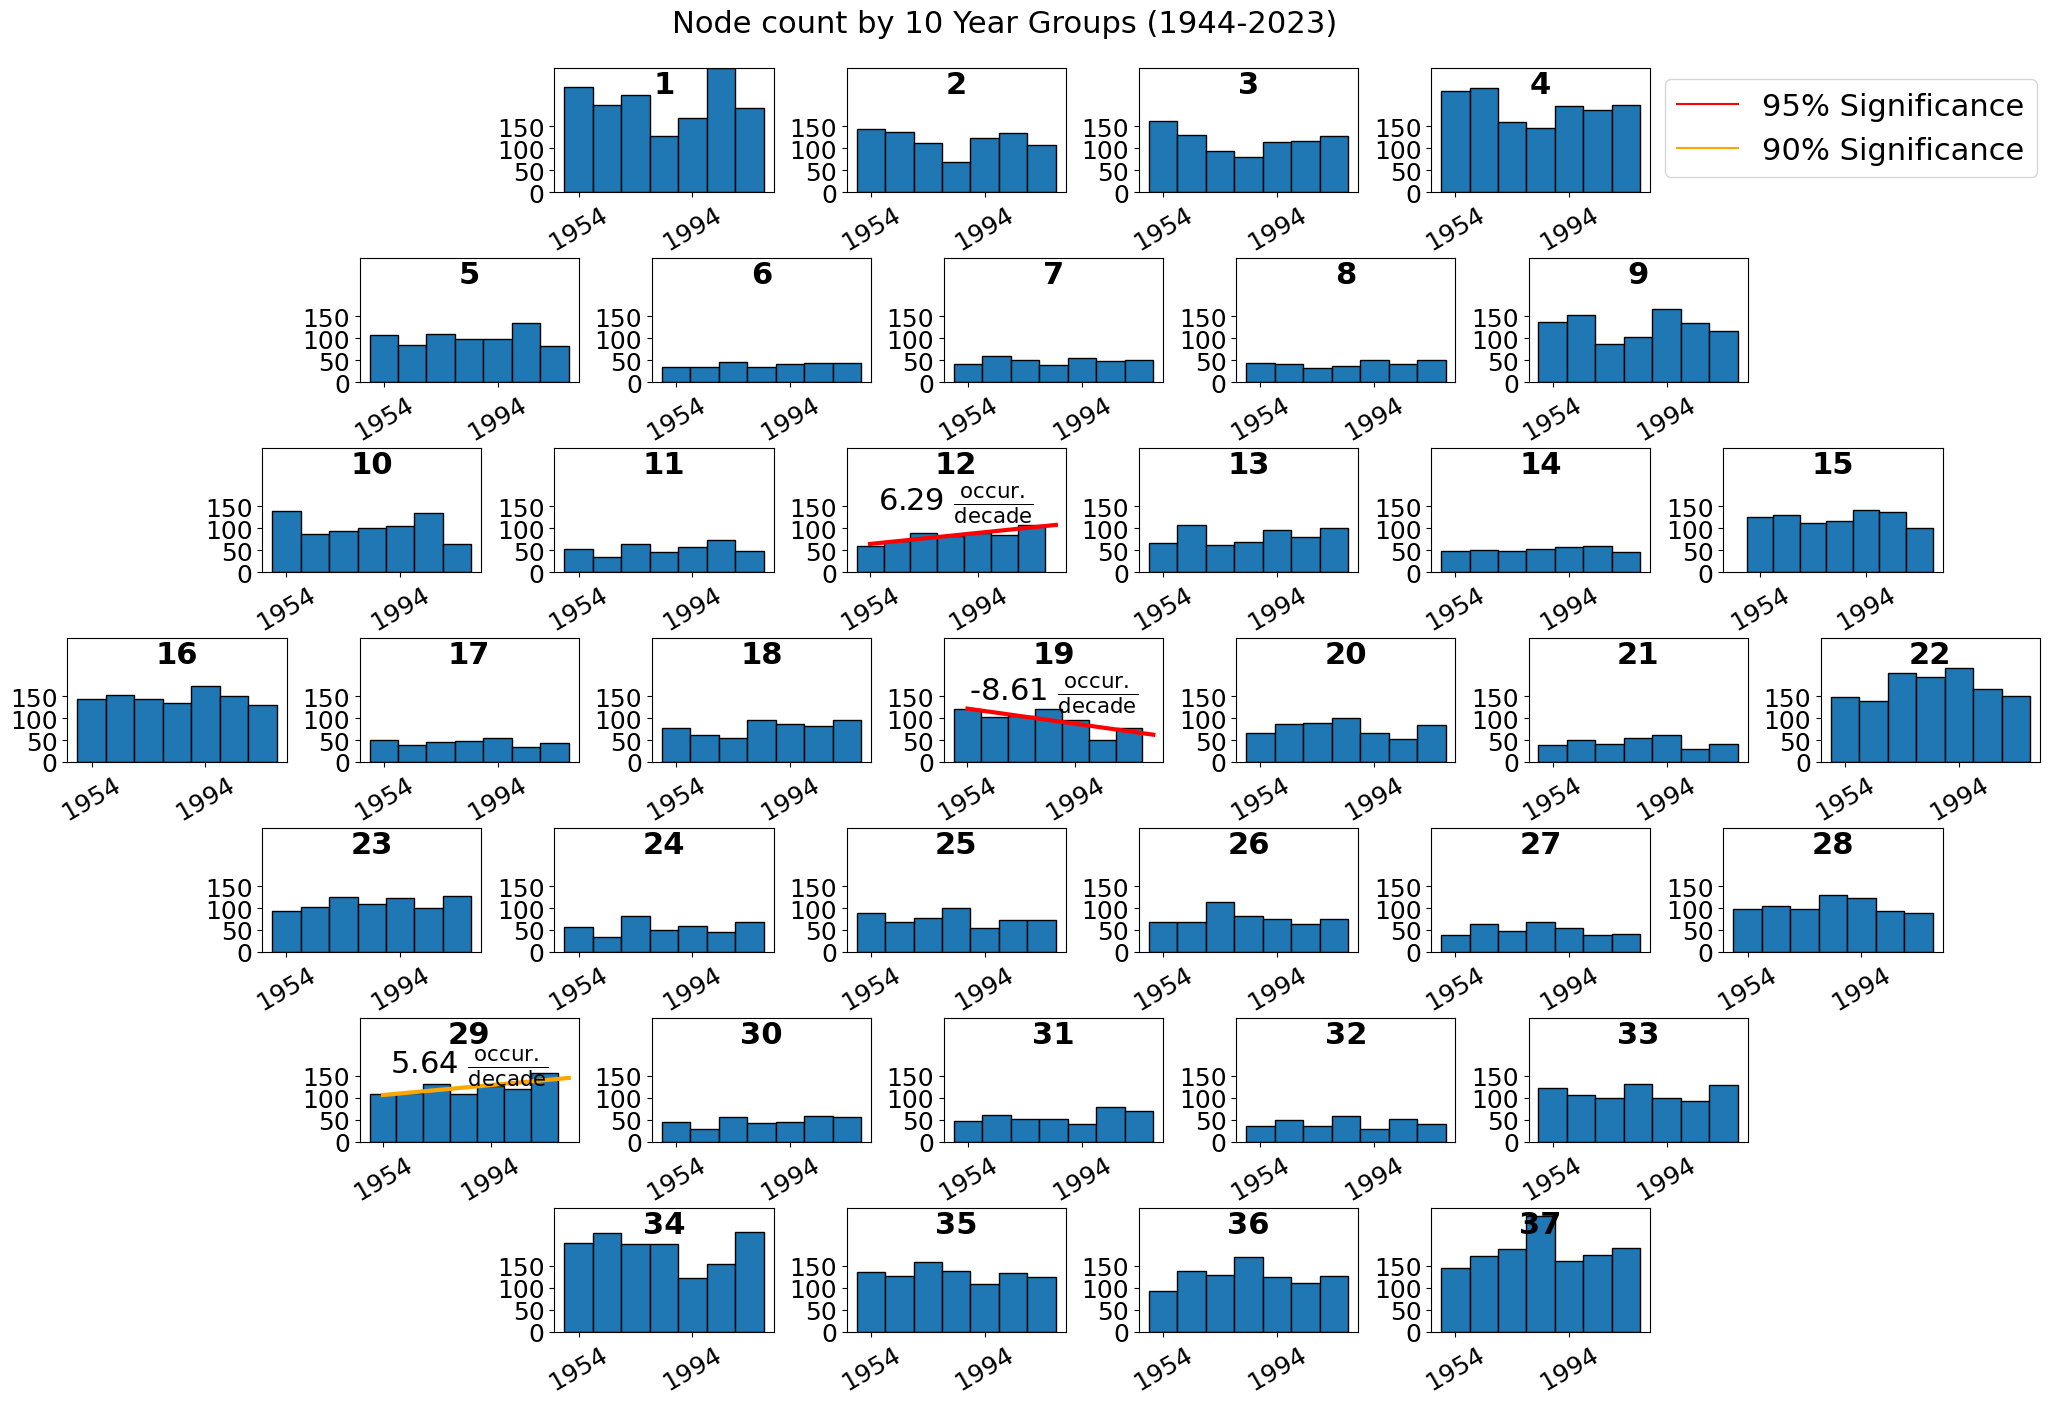

In [33]:
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 175

fs = 22
i = 0

for node, indices in winmap.items():
    
    bin_size = 10  #in years
    ax = axs[node[0], node[1]]

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Keep track of the largest bin
    if max(groups) > maxBin:
        maxBin = max(groups)

    # Plot the bins as a bar plot
    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')
    
    lower95, upper95 = sig95[i]
    lower90, upper90 = sig90[i]
    i += 1
    
    # Calculate the trend of the actual data
    z = np.polyfit(groups.index, groups, 1)
    
    # Plot trend only if it is significant
    if z[0] >= upper90 or z[0] <= lower90:
        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)
        
        if node == (1, 1):
            ax.text(
                .5, .55, 
                f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        # Plot with different colors depending on significance
        if z[0] >= upper95 or z[0] <= lower95:
            color = 'r'
        else:
            color = 'orange'
            
        ax.plot(x, y, c=color, linewidth=3)
        
    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 50, 100, 150])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

    # double checking
    #print(node_nums[node], groups.values[0])
    
# Loop through each axis to change y axis scale
for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("Node count by 10 Year Groups (1944-2023)", y=1.0, fontsize=22)
fig.tight_layout()

# Create dummy data so a legend can be made for the significance
plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig(f'node_count_trends_{reanalysis}.png', transparent=True, bbox_inches='tight')
plt.show()

## DJF

In [157]:
# Calculate the significance
sig95 = []
sig90 = []

for node, indices in DJF_winmap.items():
    
    bin_size = 10  #in years

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Calculate the significance of the trend
    lower95, upper95 = trend_significance(groups)
    lower90, upper90 = trend_significance(groups, alpha=.1)
    
    sig95.append((lower95, upper95))
    sig90.append((lower90, upper90))

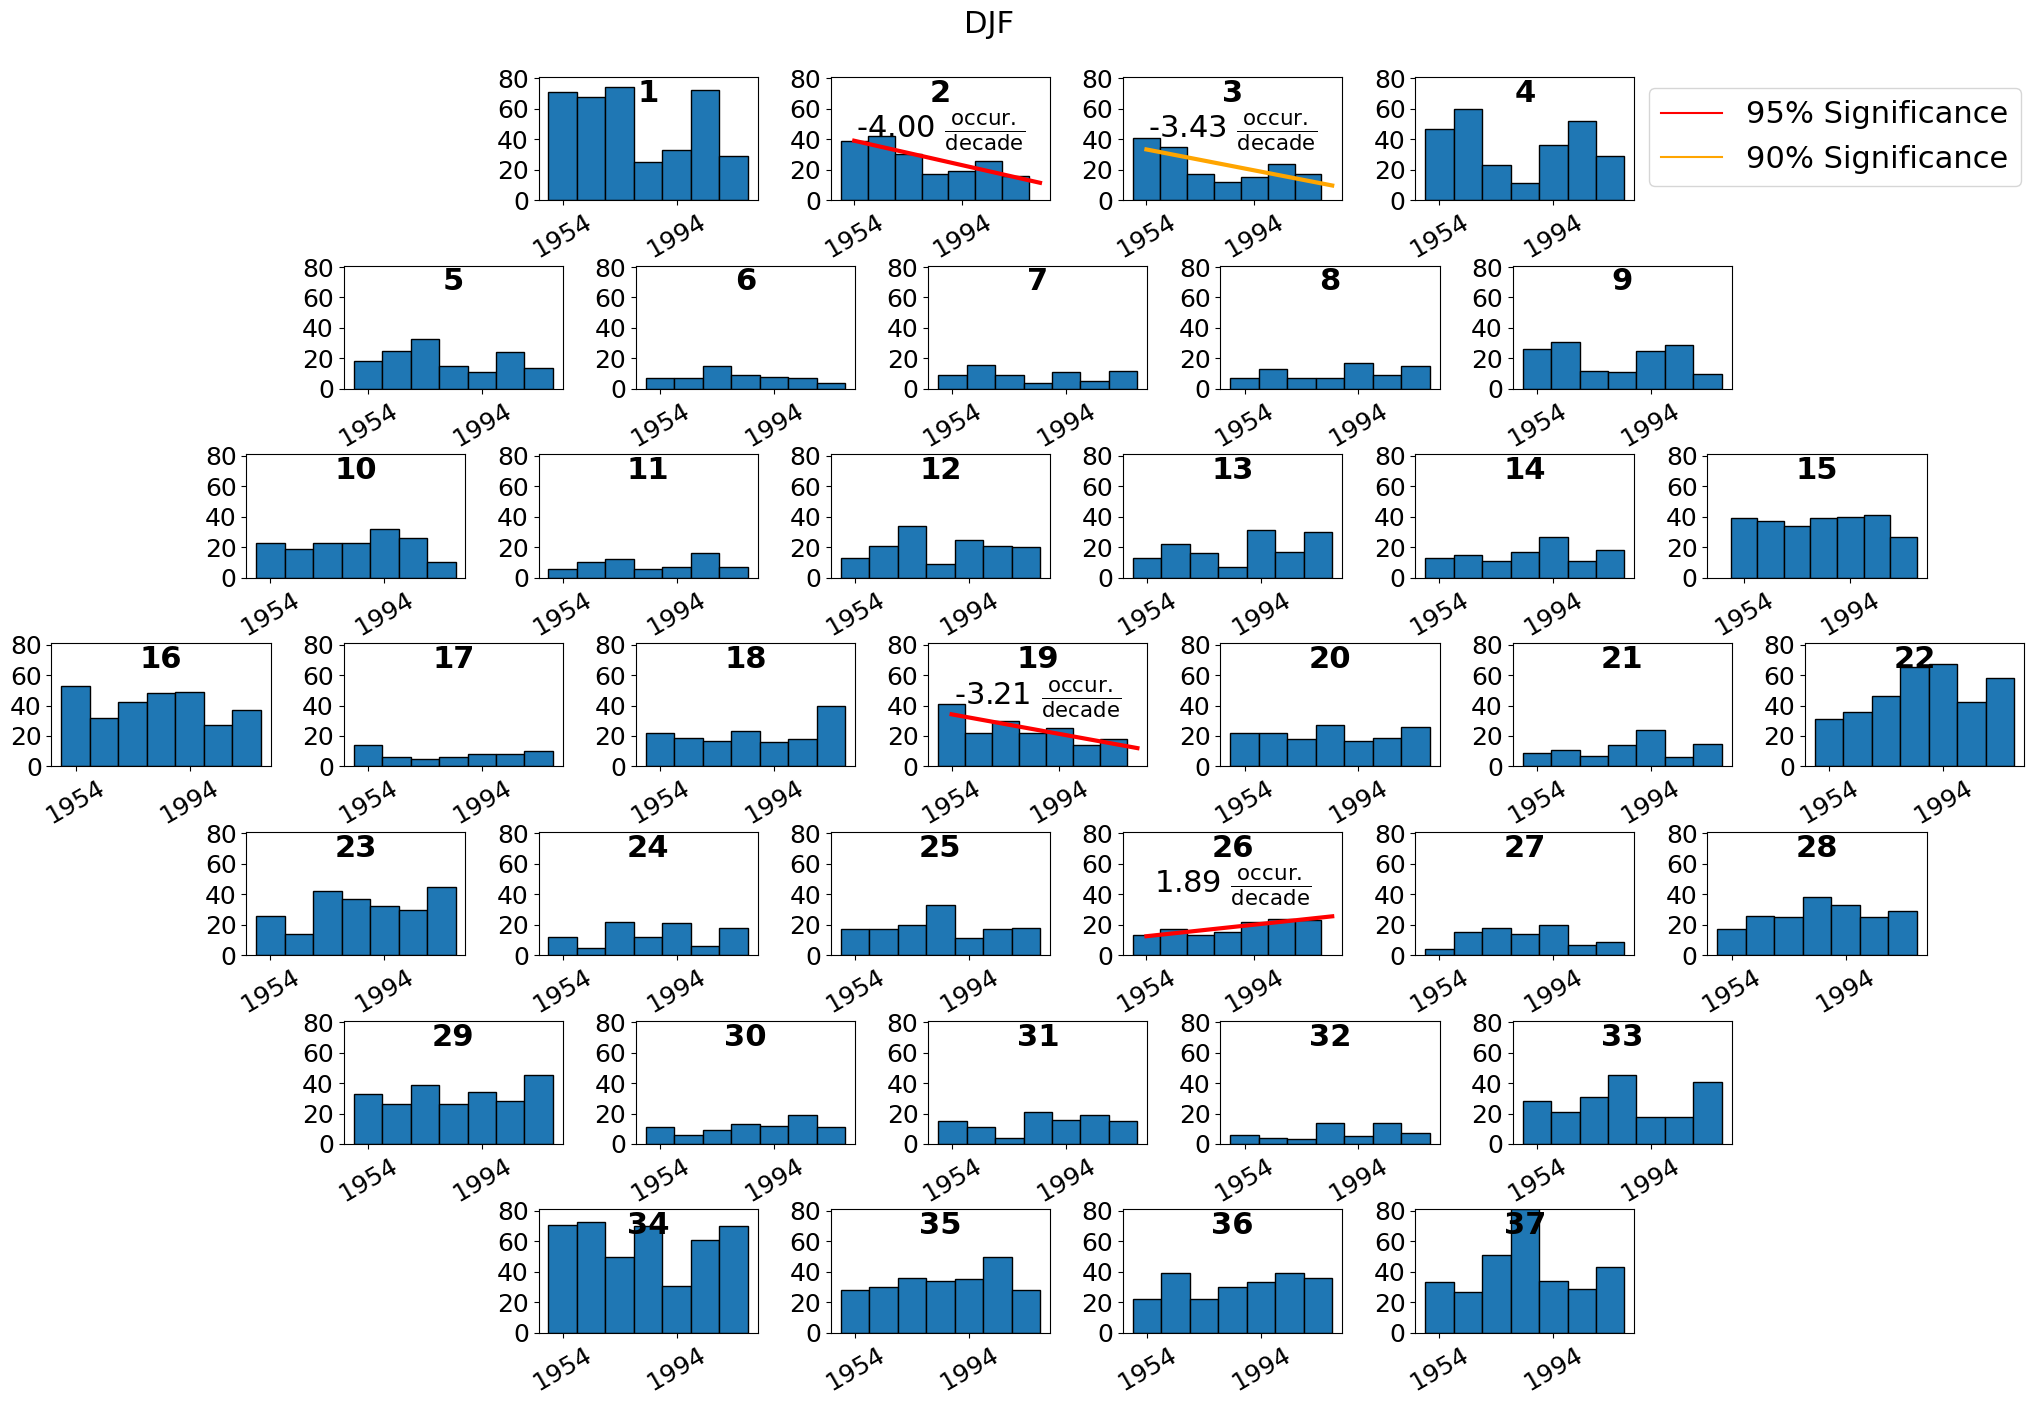

In [158]:
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 80

fs = 22
i = 0

for node, indices in DJF_winmap.items():
    
    bin_size = 10  #in years
    ax = axs[node[0], node[1]]

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Keep track of the largest bin
    if max(groups) > maxBin:
        maxBin = max(groups)

    # Plot the bins as a bar plot
    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')
    
    lower95, upper95 = sig95[i]
    lower90, upper90 = sig90[i]
    i += 1
    
    # Calculate the trend of the actual data
    z = np.polyfit(groups.index, groups, 1)
    
    # Plot trend only if it is significant
    if z[0] >= upper90 or z[0] <= lower90:
        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)
        
        if node == (1, 1):
            ax.text(
                .5, .55, 
                f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        # Plot with different colors depending on significance
        if z[0] >= upper95 or z[0] <= lower95:
            color = 'r'
        else:
            color = 'orange'
            
        ax.plot(x, y, c=color, linewidth=3)
        
    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60, 80])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

    # double checking
    #print(node_nums[node], groups.values[0])
    
# Loop through each axis to change y axis scale
for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("DJF", y=1.0, fontsize=22)
fig.tight_layout()

# Create dummy data so a legend can be made for the significance
plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig(f'node_count_trends_DJF_{reanalysis}.pdf', transparent=True, bbox_inches='tight')
plt.show()

## MAM

In [159]:
# Calculate the significance
sig95 = []
sig90 = []

for node, indices in MAM_winmap.items():
    
    bin_size = 10  #in years

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Calculate the significance of the trend
    lower95, upper95 = trend_significance(groups)
    lower90, upper90 = trend_significance(groups, alpha=.1)
    
    sig95.append((lower95, upper95))
    sig90.append((lower90, upper90))

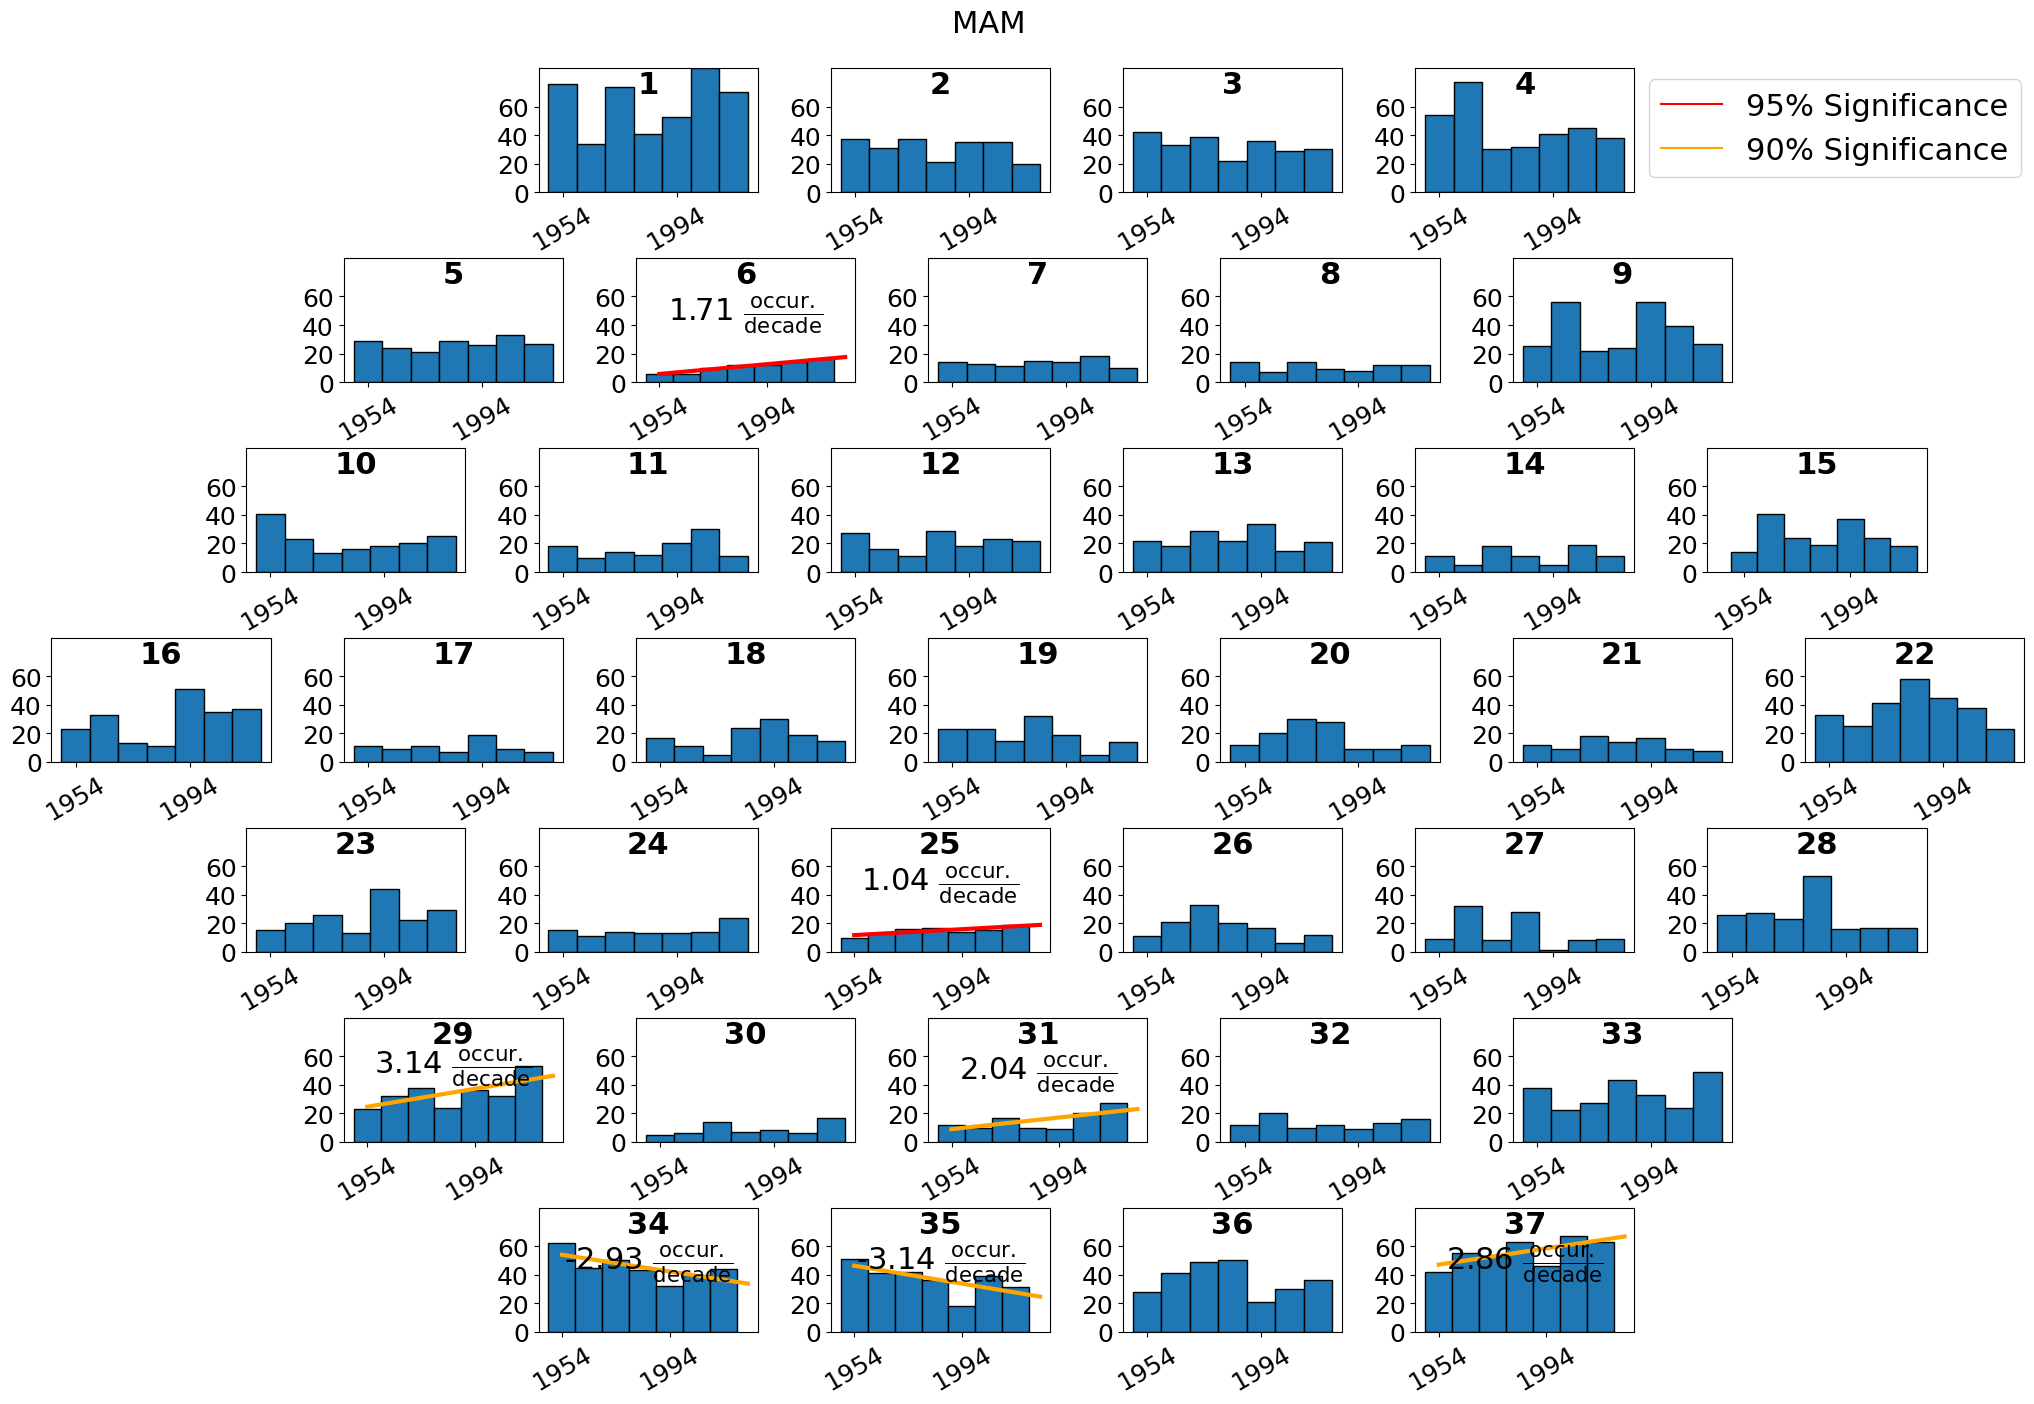

In [160]:
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 65

fs = 22
i = 0

for node, indices in MAM_winmap.items():
    
    bin_size = 10  #in years
    ax = axs[node[0], node[1]]

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Keep track of the largest bin
    if max(groups) > maxBin:
        maxBin = max(groups)

    # Plot the bins as a bar plot
    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')
    
    lower95, upper95 = sig95[i]
    lower90, upper90 = sig90[i]
    i += 1
    
    # Calculate the trend of the actual data
    z = np.polyfit(groups.index, groups, 1)
    
    # Plot trend only if it is significant
    if z[0] >= upper90 or z[0] <= lower90:
        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)
        
        if node == (1, 1):
            ax.text(
                .5, .55, 
                f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        # Plot with different colors depending on significance
        if z[0] >= upper95 or z[0] <= lower95:
            color = 'r'
        else:
            color = 'orange'
            
        ax.plot(x, y, c=color, linewidth=3)
        
    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

    # double checking
    #print(node_nums[node], groups.values[0])
    
# Loop through each axis to change y axis scale
for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("MAM", y=1.0, fontsize=22)
fig.tight_layout()

# Create dummy data so a legend can be made for the significance
plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig(f'node_count_trends_MAM_{reanalysis}.pdf', transparent=True, bbox_inches='tight')
plt.show()

## JJA

In [161]:
# Calculate the significance
sig95 = []
sig90 = []

for node, indices in JJA_winmap.items():
    
    bin_size = 10  #in years

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Calculate the significance of the trend
    lower95, upper95 = trend_significance(groups)
    lower90, upper90 = trend_significance(groups, alpha=.1)
    
    sig95.append((lower95, upper95))
    sig90.append((lower90, upper90))

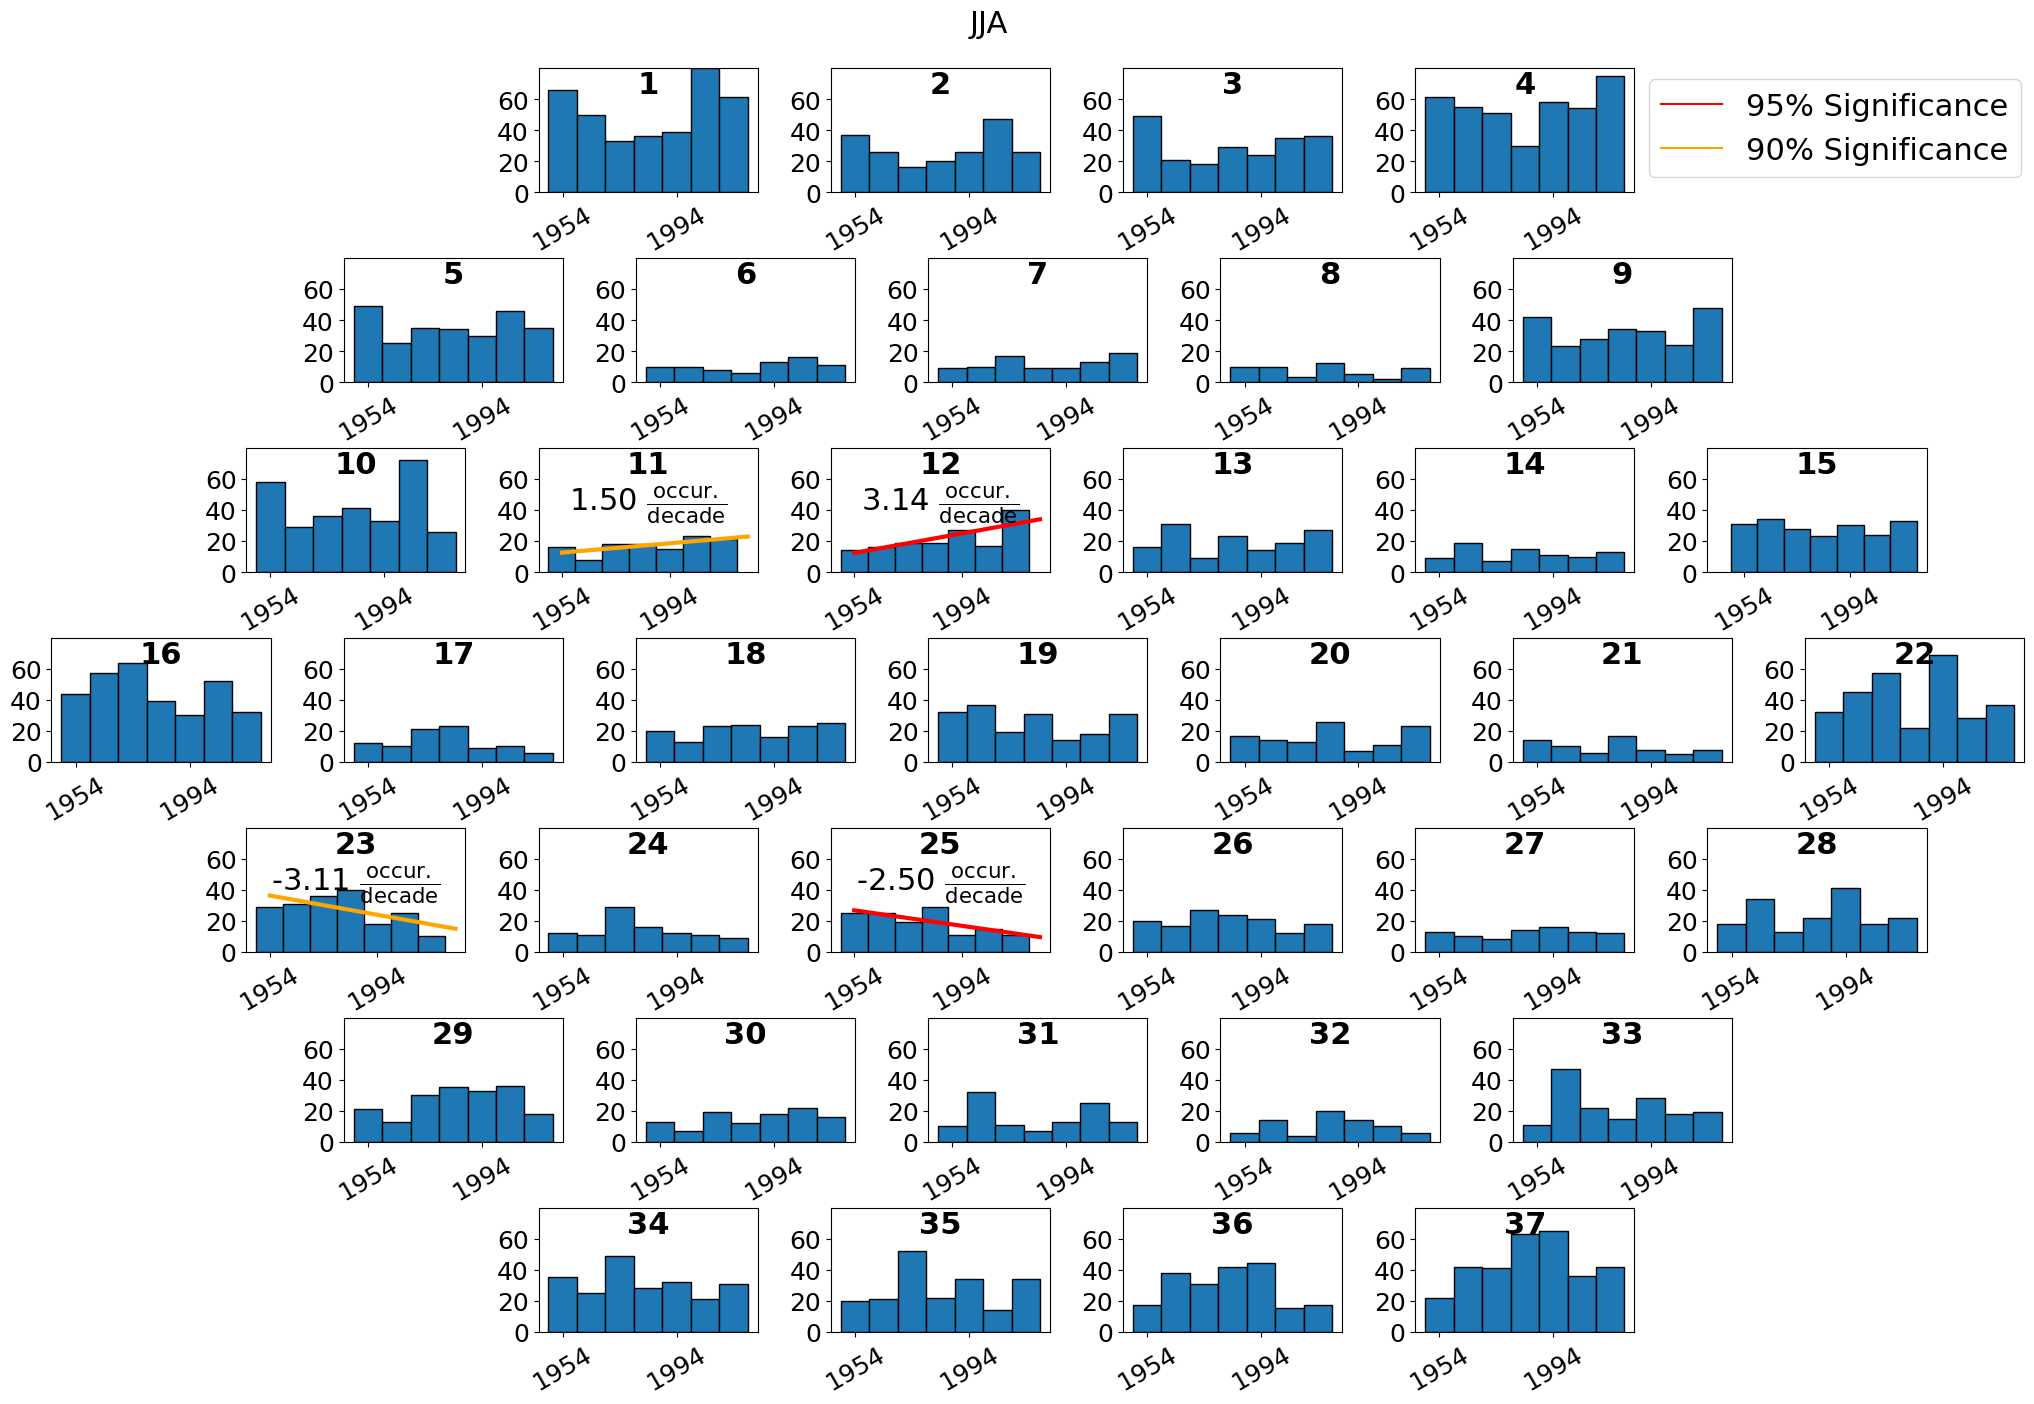

In [162]:
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 60

fs = 22
i = 0

for node, indices in JJA_winmap.items():
    
    bin_size = 10  #in years
    ax = axs[node[0], node[1]]

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Keep track of the largest bin
    if max(groups) > maxBin:
        maxBin = max(groups)

    # Plot the bins as a bar plot
    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')
    
    lower95, upper95 = sig95[i]
    lower90, upper90 = sig90[i]
    i += 1
    
    # Calculate the trend of the actual data
    z = np.polyfit(groups.index, groups, 1)
    
    # Plot trend only if it is significant
    if z[0] >= upper90 or z[0] <= lower90:
        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)
        
        if node == (1, 1):
            ax.text(
                .5, .55, 
                f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        # Plot with different colors depending on significance
        if z[0] >= upper95 or z[0] <= lower95:
            color = 'r'
        else:
            color = 'orange'
            
        ax.plot(x, y, c=color, linewidth=3)
        
    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

    # double checking
    #print(node_nums[node], groups.values[0])
    
# Loop through each axis to change y axis scale
for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("JJA", y=1.0, fontsize=22)
fig.tight_layout()

# Create dummy data so a legend can be made for the significance
plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig(f'node_count_trends_JJA_{reanalysis}.pdf', transparent=True, bbox_inches='tight')
plt.show()

## SON

In [163]:
# Calculate the significance
sig95 = []
sig90 = []

for node, indices in SON_winmap.items():
    
    bin_size = 10  #in years

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Calculate the significance of the trend
    lower95, upper95 = trend_significance(groups)
    lower90, upper90 = trend_significance(groups, alpha=.1)
    
    sig95.append((lower95, upper95))
    sig90.append((lower90, upper90))

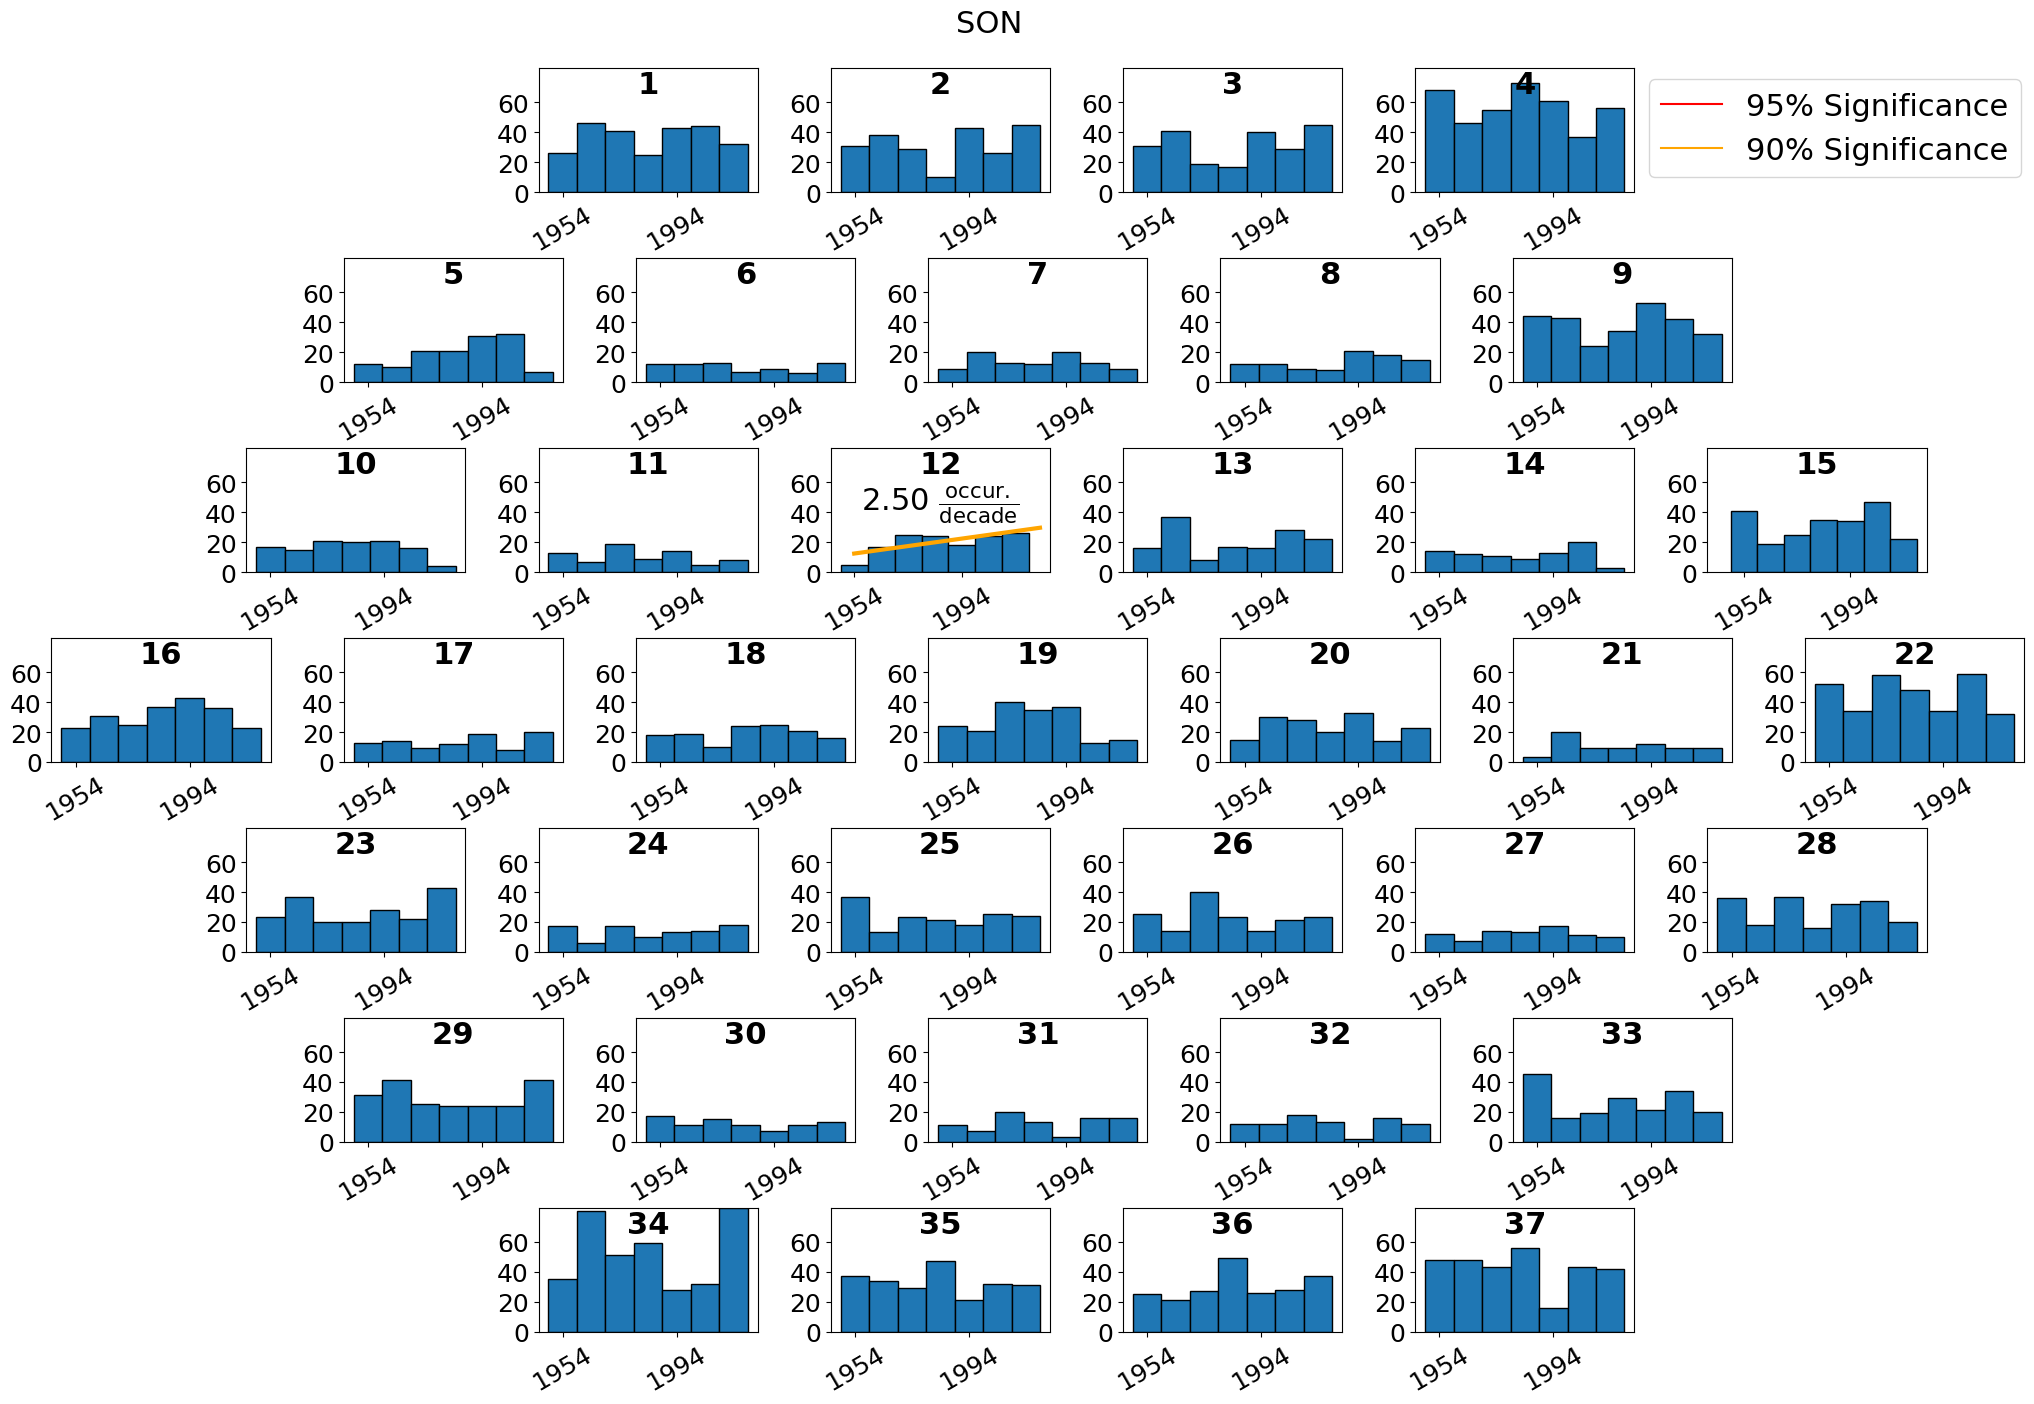

In [164]:
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 60

fs = 22
i = 0

for node, indices in SON_winmap.items():
    
    bin_size = 10  #in years
    ax = axs[node[0], node[1]]

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    
    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])
    
    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()
    
    # Keep track of the largest bin
    if max(groups) > maxBin:
        maxBin = max(groups)

    # Plot the bins as a bar plot
    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')
    
    lower95, upper95 = sig95[i]
    lower90, upper90 = sig90[i]
    i += 1
    
    # Calculate the trend of the actual data
    z = np.polyfit(groups.index, groups, 1)
    
    # Plot trend only if it is significant
    if z[0] >= upper90 or z[0] <= lower90:
        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)
        
        if node == (1, 1):
            ax.text(
                .5, .55, 
                f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{occur.}}{\text{decade}}$', 
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        # Plot with different colors depending on significance
        if z[0] >= upper95 or z[0] <= lower95:
            color = 'r'
        else:
            color = 'orange'
            
        ax.plot(x, y, c=color, linewidth=3)
        
    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

    # double checking
    #print(node_nums[node], groups.values[0])
    
# Loop through each axis to change y axis scale
for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("SON", y=1.0, fontsize=22)
fig.tight_layout()

# Create dummy data so a legend can be made for the significance
plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig(f'node_count_trends_SON_{reanalysis}.pdf', transparent=True, bbox_inches='tight')
plt.show()